Loading embeddings...
Debian (source): (18298, 768) (vuln=1415, non-vuln=16883)
Chrome (target): (4436, 768) (vuln=825, non-vuln=3611)

=== [1/4] SMOTE ===
  Loading cached SMOTE embeddings from disk...
  Panel A total points: 22734 | Panel B total points: 38202
  Running t-SNE on 22734 points (Panel A - Baseline)...
  Running t-SNE on 38202 points (Panel B - SMOTE)...
  Figure saved: results/tsne_reveal/tsne_domain_shift_smote.pdf
  Figure saved: results/tsne_reveal/tsne_domain_shift_smote.png


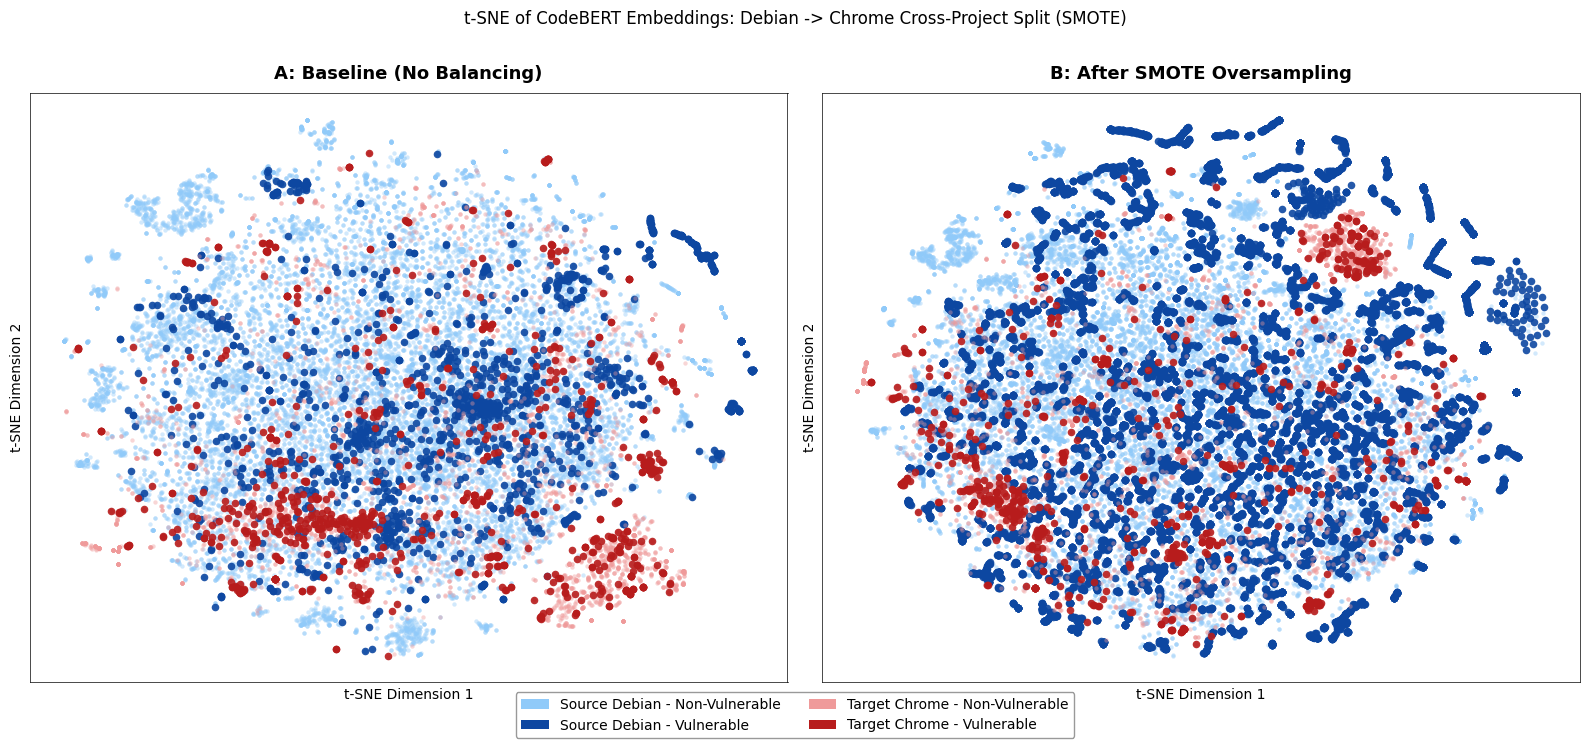


=== [2/4] ADASYN ===
  Loading cached ADASYN embeddings from disk...
  Panel A total points: 22734 | Panel B total points: 37957
  Running t-SNE on 22734 points (Panel A - Baseline)...
  Running t-SNE on 37957 points (Panel B - ADASYN)...
  Figure saved: results/tsne_reveal/tsne_domain_shift_adasyn.pdf
  Figure saved: results/tsne_reveal/tsne_domain_shift_adasyn.png


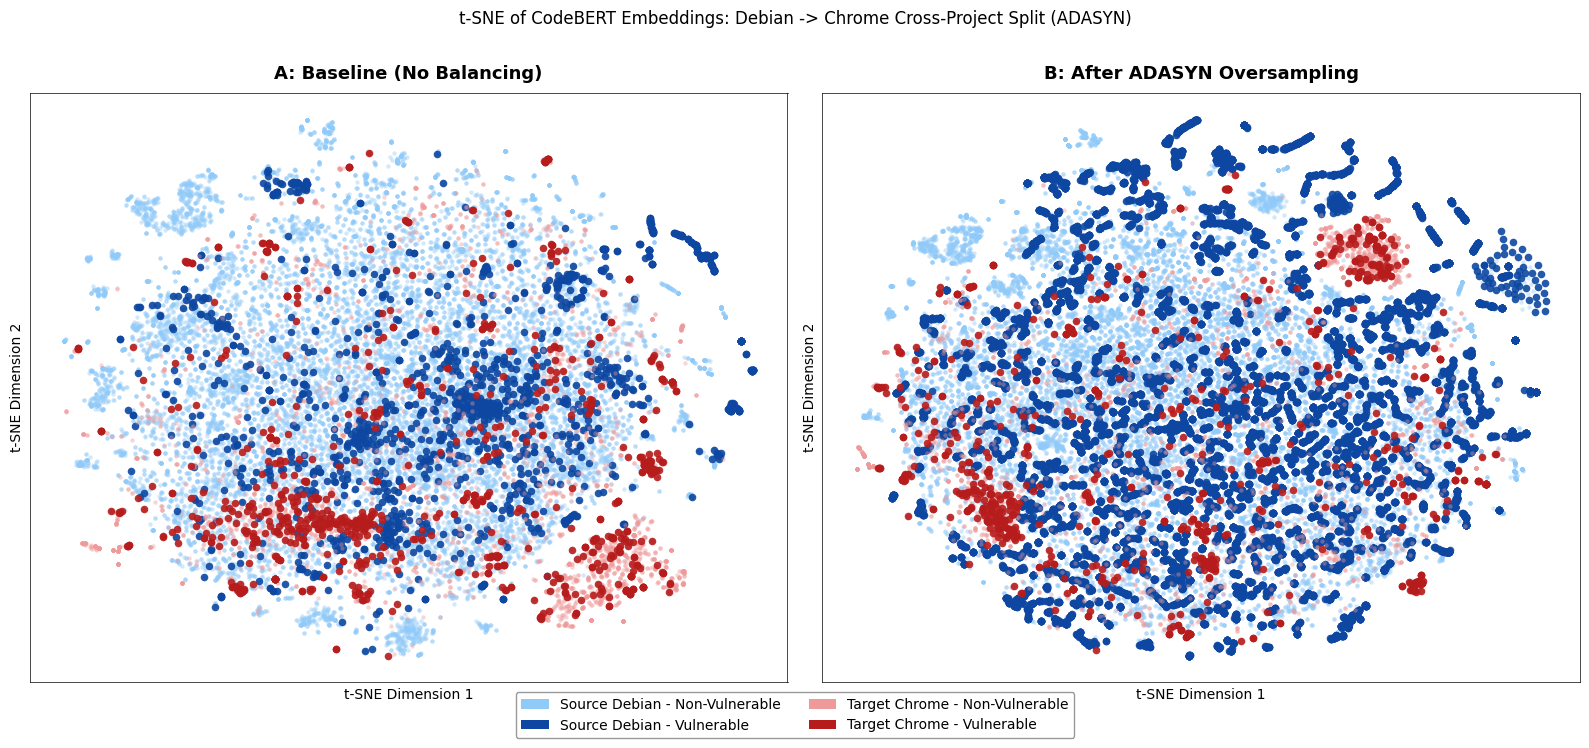


=== [3/4] SVMSMOTE ===
  Loading cached SVMSMOTE embeddings from disk...
  Panel A total points: 22734 | Panel B total points: 38202
  Running t-SNE on 22734 points (Panel A - Baseline)...
  Running t-SNE on 38202 points (Panel B - SVMSMOTE)...
  Figure saved: results/tsne_reveal/tsne_domain_shift_svmsmote.pdf
  Figure saved: results/tsne_reveal/tsne_domain_shift_svmsmote.png


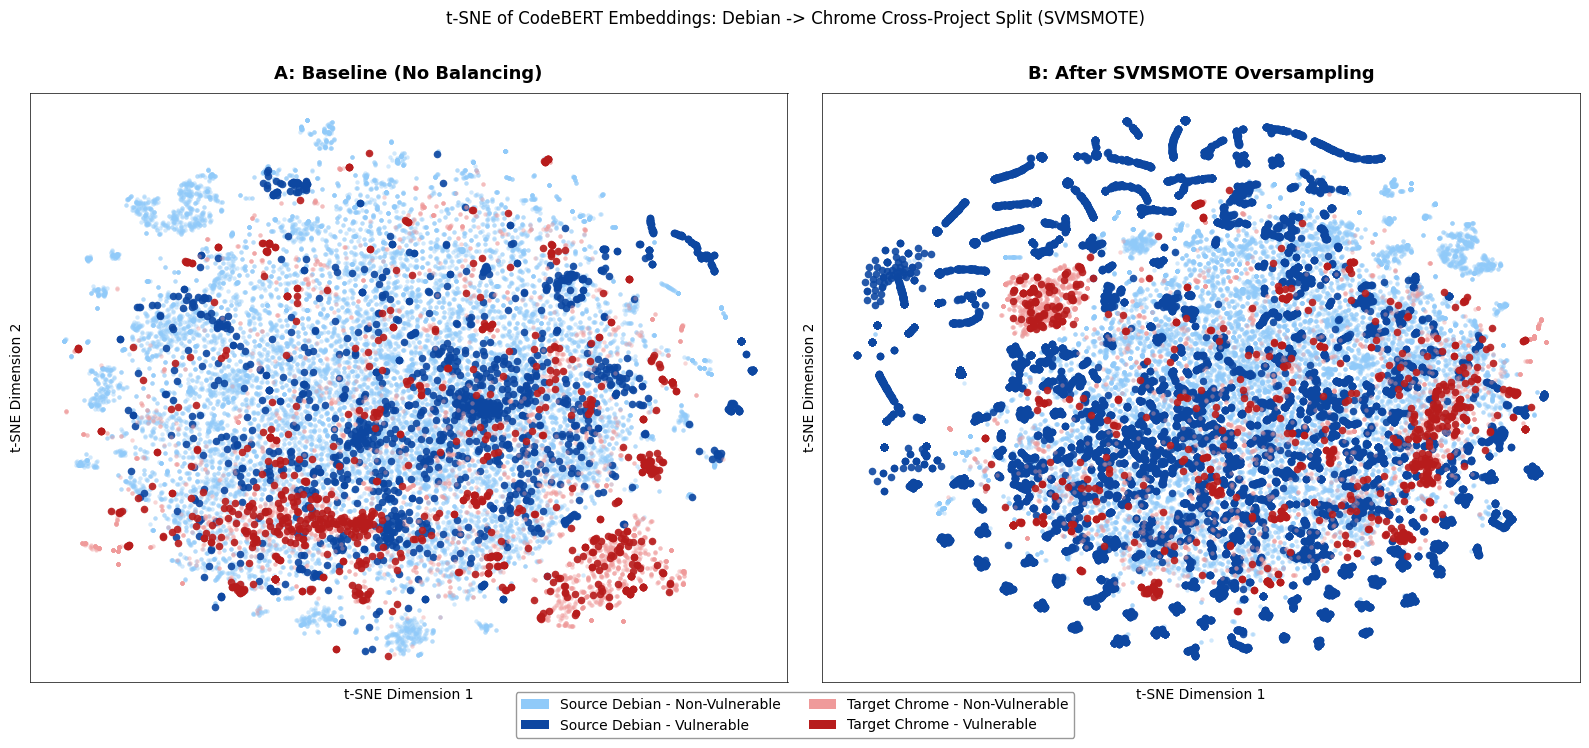


=== [4/4] GAN ===
  Loading cached GAN embeddings from disk...
  Panel A total points: 22734 | Panel B total points: 38202
  Running t-SNE on 22734 points (Panel A - Baseline)...
  Running t-SNE on 38202 points (Panel B - GAN)...
  Figure saved: results/tsne_reveal/tsne_domain_shift_gan.pdf
  Figure saved: results/tsne_reveal/tsne_domain_shift_gan.png


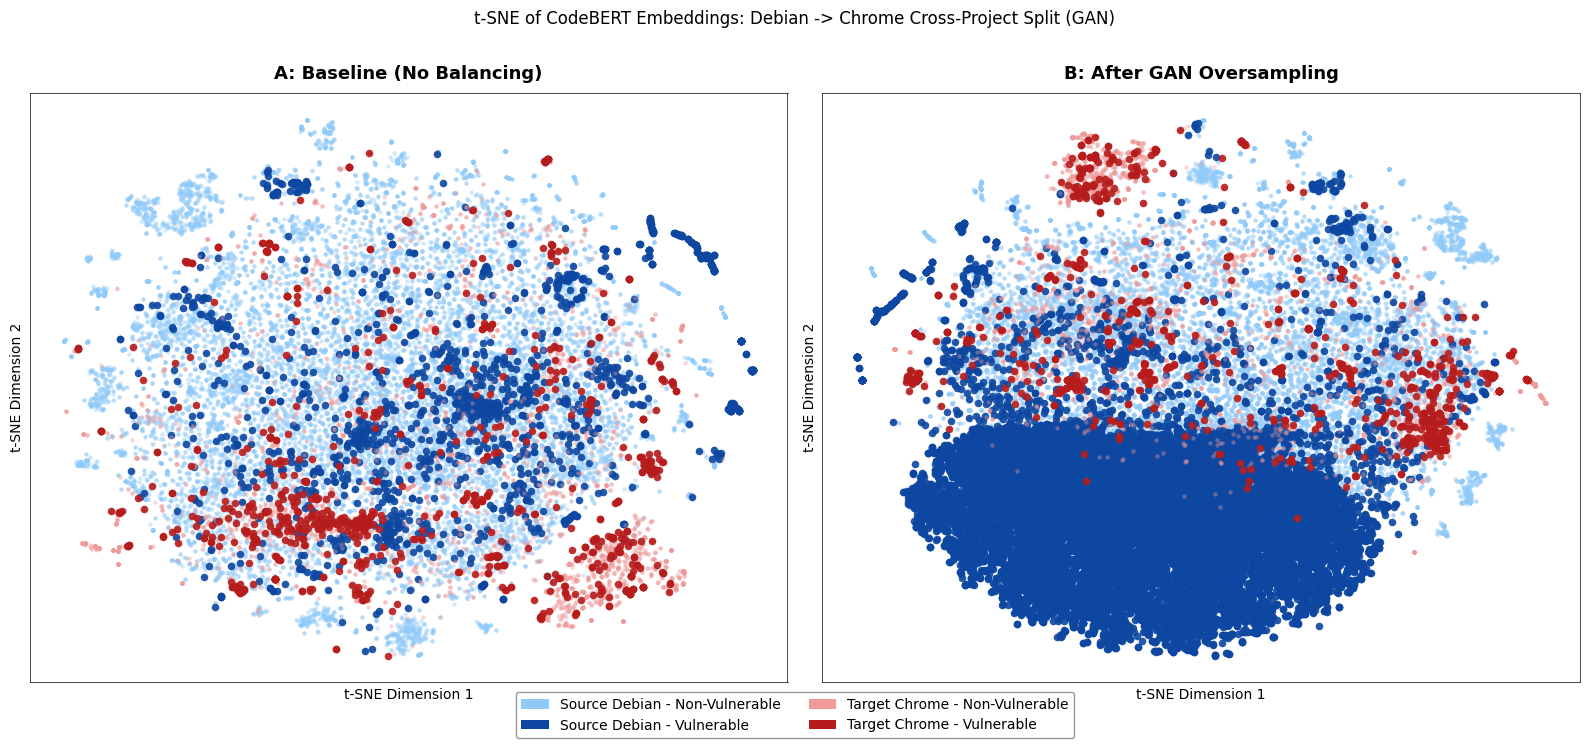


ALL METHODS PROCESSED.
Figures saved in: results/tsne_reveal


In [2]:
"""
t-SNE Domain Shift Visualisation for ReVeal (Debian -> Chrome)
------------------------------------------------------------------
Generates one Baseline vs Method panel figure per oversampling method
"""

import os
import gc
import time
import warnings
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE, ADASYN, SVMSMOTE

warnings.filterwarnings("ignore")


DATASET_DIR = "../../../../../embedding/reveal/codebert/"
OUTPUT_DIR  = "results/tsne_reveal"
SEED        = 42

TSNE_PERPLEXITY = 30
TSNE_LEARNING_RATE = 200
TSNE_MAX_ITER = 1000

GAN_LATENT_DIM  = 100
GAN_EPOCHS      = 1500
GAN_BATCH_SIZE  = 64
GAN_LOG_EVERY   = 500

os.makedirs(OUTPUT_DIR, exist_ok=True)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = "mps"
    torch.mps.manual_seed(SEED)
elif torch.cuda.is_available():
    DEVICE = "cuda"
    torch.cuda.manual_seed_all(SEED)
else:
    DEVICE = "cpu"

METHODS = ["SMOTE", "ADASYN", "SVMSMOTE", "GAN"]

CACHE_FILES = {
    "SMOTE": f"{DATASET_DIR}/debian_smote.npy",
    "ADASYN": f"{DATASET_DIR}/debian_adasyn.npy",
    "SVMSMOTE": f"{DATASET_DIR}/debian_svmsmote.npy",
    "GAN": f"{DATASET_DIR}/debian_gan_embeddings.npy",
}

COLORS = {
    (0, 0): "#90CAF9", (0, 1): "#0D47A1",
    (1, 0): "#EF9A9A", (1, 1): "#B71C1C",
}
ALPHA = {0: 0.40, 1: 0.90}
SIZE  = {0: 10, 1: 30}


class Generator(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, output_dim)
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


def load_data():
    print("Loading embeddings...")
    deb_emb = np.load(f"{DATASET_DIR}/debian_embeddings.npy").astype(np.float32)
    deb_lbl = np.load(f"{DATASET_DIR}/debian_labels.npy").astype(int)
    chr_emb = np.load(f"{DATASET_DIR}/chrome_embeddings.npy").astype(np.float32)
    chr_lbl = np.load(f"{DATASET_DIR}/chrome_labels.npy").astype(int)

    scaler = StandardScaler()
    deb_emb_scaled = scaler.fit_transform(deb_emb).astype(np.float32)
    chr_emb_scaled = scaler.transform(chr_emb).astype(np.float32)

    print(f"Debian (source): {deb_emb_scaled.shape} (vuln={int(deb_lbl.sum())}, "
          f"non-vuln={int((deb_lbl == 0).sum())})")
    print(f"Chrome (target): {chr_emb_scaled.shape} (vuln={int(chr_lbl.sum())}, "
          f"non-vuln={int((chr_lbl == 0).sum())})")

    return deb_emb_scaled, deb_lbl, chr_emb_scaled, chr_lbl


def generate_gan_embeddings(source_emb, source_lbl):
    input_dim = source_emb.shape[1]
    minority_emb = source_emb[source_lbl == 1].astype(np.float32)
    n_to_generate = int(np.sum(source_lbl == 0)) - int(np.sum(source_lbl == 1))

    print(f"    Minority samples: {minority_emb.shape[0]} | Target to generate: {n_to_generate}")

    G = Generator(GAN_LATENT_DIM, input_dim).to(DEVICE)
    D = Discriminator(input_dim).to(DEVICE)
    opt_G = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
    opt_D = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
    criterion = nn.BCELoss()

    minority_tensor = torch.tensor(minority_emb).to(DEVICE)
    dataset = TensorDataset(minority_tensor)
    loader = DataLoader(dataset, batch_size=GAN_BATCH_SIZE, shuffle=True)

    t0 = time.time()
    epoch_bar = tqdm(range(GAN_EPOCHS), desc="    GAN training", leave=False)
    for epoch in epoch_bar:
        for (real_batch,) in loader:
            bs = real_batch.size(0)

            z = torch.randn(bs, GAN_LATENT_DIM).to(DEVICE)
            fake = G(z).detach()
            loss_D = criterion(D(real_batch), torch.ones(bs, 1).to(DEVICE)) + \
                     criterion(D(fake), torch.zeros(bs, 1).to(DEVICE))
            opt_D.zero_grad()
            loss_D.backward()
            opt_D.step()

            z = torch.randn(bs, GAN_LATENT_DIM).to(DEVICE)
            loss_G = criterion(D(G(z)), torch.ones(bs, 1).to(DEVICE))
            opt_G.zero_grad()
            loss_G.backward()
            opt_G.step()

        if (epoch + 1) % GAN_LOG_EVERY == 0:
            epoch_bar.set_postfix({"D_loss": f"{loss_D.item():.4f}", "G_loss": f"{loss_G.item():.4f}"})

    print(f"    GAN training complete in {time.time() - t0:.1f}s")

    G.eval()
    with torch.no_grad():
        z = torch.randn(n_to_generate, GAN_LATENT_DIM).to(DEVICE)
        synthetic = G(z).cpu().numpy()

    resampled_emb = np.vstack([source_emb, synthetic]).astype(np.float32)
    resampled_lbl = np.concatenate([source_lbl, np.ones(n_to_generate, dtype=int)])

    del G, D, opt_G, opt_D, minority_tensor, dataset, loader
    gc.collect()
    if DEVICE == "mps":
        torch.mps.empty_cache()
    elif DEVICE == "cuda":
        torch.cuda.empty_cache()

    return resampled_emb, resampled_lbl


def load_source_for_method(method, deb_emb_scaled, deb_lbl):
    cache_path = CACHE_FILES[method]
    if os.path.exists(cache_path):
        print(f"  Loading cached {method} embeddings from disk...")
        resampled_emb = np.load(cache_path).astype(np.float32)
        n_new = resampled_emb.shape[0] - deb_emb_scaled.shape[0]
        resampled_lbl = np.concatenate([deb_lbl, np.ones(n_new, dtype=int)]) if n_new > 0 else deb_lbl
        return resampled_emb, resampled_lbl

    print(f"  No cache found for {method} -- generating now...")
    t0 = time.time()

    if method == "SMOTE":
        sampler = SMOTE(random_state=SEED)
        resampled_emb, resampled_lbl = sampler.fit_resample(deb_emb_scaled, deb_lbl)
    elif method == "ADASYN":
        sampler = ADASYN(random_state=SEED)
        resampled_emb, resampled_lbl = sampler.fit_resample(deb_emb_scaled, deb_lbl)
    elif method == "SVMSMOTE":
        sampler = SVMSMOTE(random_state=SEED)
        resampled_emb, resampled_lbl = sampler.fit_resample(deb_emb_scaled, deb_lbl)
    elif method == "GAN":
        resampled_emb, resampled_lbl = generate_gan_embeddings(deb_emb_scaled, deb_lbl)
    else:
        raise ValueError(f"Unknown method: {method}")

    resampled_emb = resampled_emb.astype(np.float32)
    np.save(cache_path, resampled_emb)
    print(f"  Generated and cached {method} embeddings in {time.time() - t0:.1f}s. "
          f"Shape: {deb_emb_scaled.shape} -> {resampled_emb.shape}")

    return resampled_emb, resampled_lbl


def run_tsne(embeddings, label):
    print(f"  Running t-SNE on {len(embeddings)} points ({label})...")
    tsne = TSNE(
        n_components=2,
        perplexity=TSNE_PERPLEXITY,
        learning_rate=TSNE_LEARNING_RATE,
        max_iter=TSNE_MAX_ITER,
        random_state=SEED,
        n_jobs=-1,
        verbose=0,
    )
    return tsne.fit_transform(embeddings)


def plot_panels(coords_a, dom_a, lbl_a, coords_b, dom_b, lbl_b, method, save_path_pdf, save_path_png):
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.subplots_adjust(wspace=0.15)

    panel_data = [
        (axes[0], coords_a, dom_a, lbl_a, "A: Baseline (No Balancing)"),
        (axes[1], coords_b, dom_b, lbl_b, f"B: After {method} Oversampling"),
    ]

    for ax, coords, domains, labels, title in panel_data:
        for domain in [0, 1]:
            for cls in [0, 1]:
                mask = (domains == domain) & (labels == cls)
                if mask.sum() == 0:
                    continue
                ax.scatter(
                    coords[mask, 0], coords[mask, 1],
                    c=COLORS[(domain, cls)],
                    s=SIZE[cls],
                    alpha=ALPHA[cls],
                    linewidths=0,
                    rasterized=True,
                )
        ax.set_title(title, fontsize=13, fontweight="bold", pad=10)
        ax.set_xlabel("t-SNE Dimension 1", fontsize=10)
        ax.set_ylabel("t-SNE Dimension 2", fontsize=10)
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        for spine in ax.spines.values():
            spine.set_linewidth(0.5)

    legend_elements = [
        mpatches.Patch(facecolor="#90CAF9", label="Source Debian - Non-Vulnerable"),
        mpatches.Patch(facecolor="#0D47A1", label="Source Debian - Vulnerable"),
        mpatches.Patch(facecolor="#EF9A9A", label="Target Chrome - Non-Vulnerable"),
        mpatches.Patch(facecolor="#B71C1C", label="Target Chrome - Vulnerable"),
    ]
    fig.legend(
        handles=legend_elements, loc="lower center", ncol=2,
        fontsize=10, frameon=True, bbox_to_anchor=(0.5, -0.04), edgecolor="grey"
    )

    fig.suptitle(
        f"t-SNE of CodeBERT Embeddings: Debian -> Chrome Cross-Project Split ({method})",
        fontsize=12, y=1.01
    )

    plt.tight_layout()
    plt.savefig(save_path_pdf, bbox_inches="tight", dpi=300)
    plt.savefig(save_path_png, bbox_inches="tight", dpi=300)
    print(f"  Figure saved: {save_path_pdf}")
    print(f"  Figure saved: {save_path_png}")
    plt.show()


def main():
    deb_emb_scaled, deb_lbl, chr_emb_scaled, chr_lbl = load_data()

    n_methods = len(METHODS)
    for m_idx, method in enumerate(METHODS, start=1):
        print(f"\n=== [{m_idx}/{n_methods}] {method} ===")

        save_path_pdf = os.path.join(OUTPUT_DIR, f"tsne_domain_shift_{method.lower()}.pdf")
        save_path_png = os.path.join(OUTPUT_DIR, f"tsne_domain_shift_{method.lower()}.png")

        if os.path.exists(save_path_pdf) and os.path.exists(save_path_png):
            print(f"  Figures already exist for {method} -- skipping.")
            continue

        try:
            deb_method_emb, deb_method_lbl = load_source_for_method(method, deb_emb_scaled, deb_lbl)

            emb_a = np.vstack([deb_emb_scaled, chr_emb_scaled])
            dom_a = np.concatenate([np.zeros(len(deb_emb_scaled), dtype=int),
                                     np.ones(len(chr_emb_scaled), dtype=int)])
            lbl_a = np.concatenate([deb_lbl, chr_lbl])

            emb_b = np.vstack([deb_method_emb, chr_emb_scaled])
            dom_b = np.concatenate([np.zeros(len(deb_method_emb), dtype=int),
                                     np.ones(len(chr_emb_scaled), dtype=int)])
            lbl_b = np.concatenate([deb_method_lbl, chr_lbl])

            print(f"  Panel A total points: {len(lbl_a)} | Panel B total points: {len(lbl_b)}")

            coords_a = run_tsne(emb_a, "Panel A - Baseline")
            coords_b = run_tsne(emb_b, f"Panel B - {method}")

            plot_panels(coords_a, dom_a, lbl_a, coords_b, dom_b, lbl_b, method,
                        save_path_pdf, save_path_png)

            del deb_method_emb, deb_method_lbl, emb_a, emb_b, coords_a, coords_b
            gc.collect()

        except Exception as e:
            print(f"  FAILED for {method}: {e}")
            continue

    print("\nALL METHODS PROCESSED.")
    print(f"Figures saved in: {OUTPUT_DIR}")


if __name__ == "__main__":
    main()